# Titanic Dataset - Mini Exploratory Data Analysis (EDA)

## Internship: Cooperative Tech AI/ML Internship
### Week 1 - Day 5

**Prepared By:** Maryam Fatima
**Date:** June 2026

---
This notebook performs a complete exploratory data analysis on the Titanic dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("../dataset/cleaned_titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Not Available,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Not Available,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Not Available,S


# 1. Dataset Overview

This section explores the dataset structure, dimensions, and column information.

In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nTotal Data Points:", df.size)

Shape of Dataset: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Total Data Points: 10692


# 2. Data Quality Assessment

This section identifies missing values, duplicate records, and inconsistent data types.

In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Duplicate Rows:
0


# 3. Data Cleaning

Missing values were handled appropriately and duplicate rows were removed.

In [5]:
# Fill missing age

df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked

df['Embarked'] = df['Embarked'].fillna('Unknown')

# Remove duplicates

df = df.drop_duplicates()

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# 4. Descriptive Statistics

Statistical summaries help understand central tendency and spread of numerical variables.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print(df['Sex'].value_counts())
print(df['Pclass'].value_counts())
print(df['Embarked'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Embarked
S          644
C          168
Q           77
Unknown      2
Name: count, dtype: int64


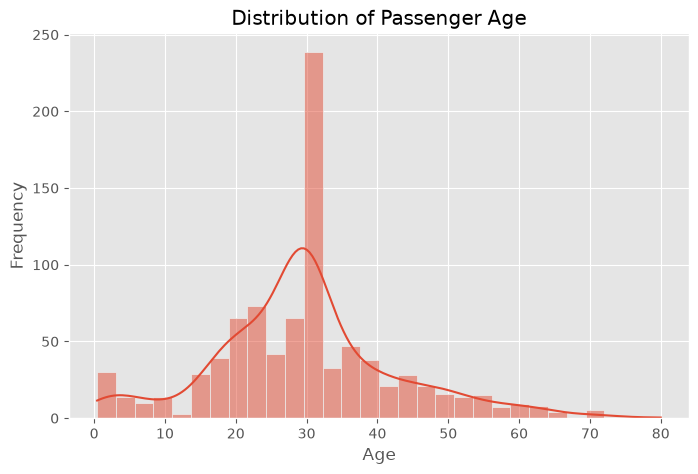

In [10]:
# Chart 1 Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.savefig('../outputs/chart1_age_distribution.png')
plt.show()

Most passengers were between 20 and 40 years old.

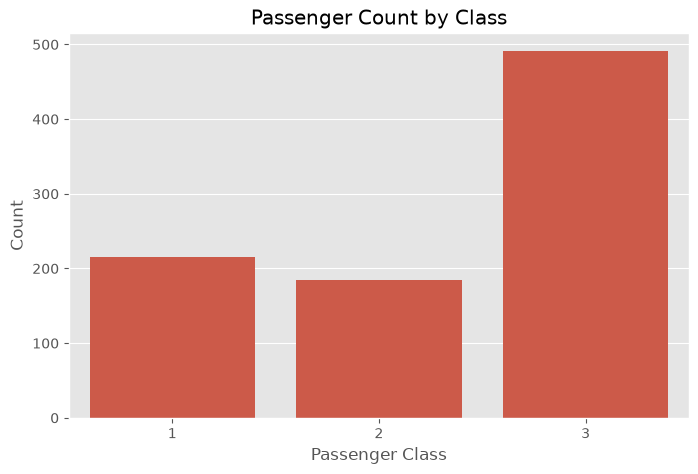

In [11]:
# Chart 2 Passenger cass count
plt.figure(figsize=(8,5))

sns.countplot(x='Pclass', data=df)

plt.title('Passenger Count by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.savefig('../outputs/chart2_class_count.png')
plt.show()

Third-class passengers were the largest group in the dataset.

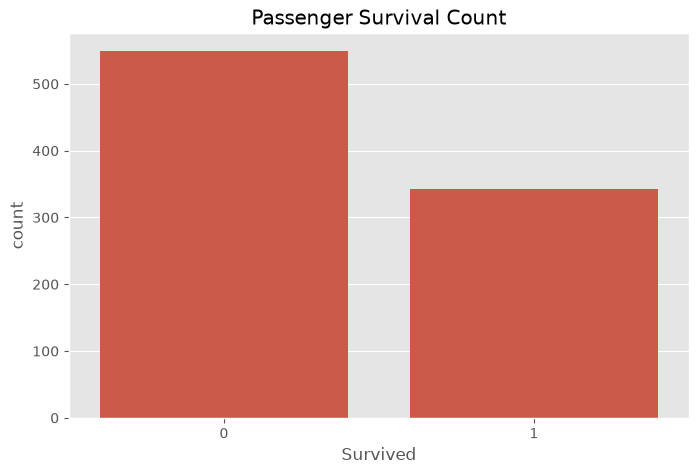

In [12]:
# Chart 3 Survival count
plt.figure(figsize=(8,5))

sns.countplot(x='Survived', data=df)

plt.title('Passenger Survival Count')

plt.savefig('../outputs/chart3_survival.png')
plt.show()

More passengers did not survive compared to those who survived.

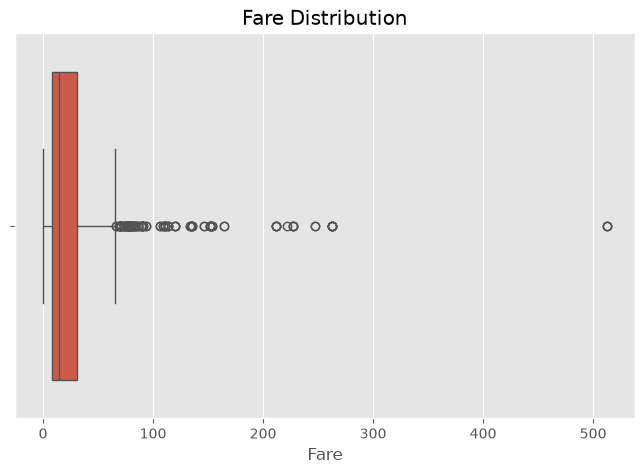

In [13]:
# Chart 4 Fare Distribution boxplot
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Fare'])

plt.title('Fare Distribution')

plt.savefig('../outputs/chart4_fare_boxplot.png')
plt.show()

The fare column contains several outliers indicating high-priced tickets.


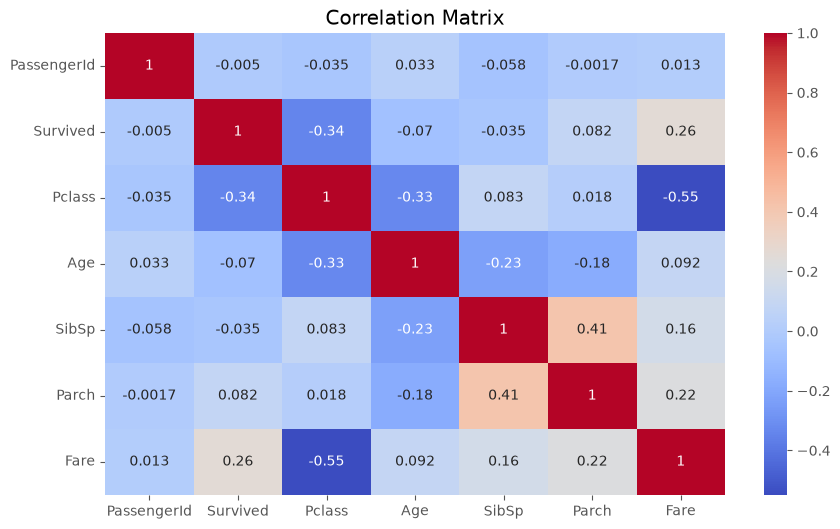

In [ ]:
# Correlational HeatMap
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')

plt.savefig('../outputs/chart5_heatmap.png')
plt.show()

Passenger class and fare show a strong negative relationship.

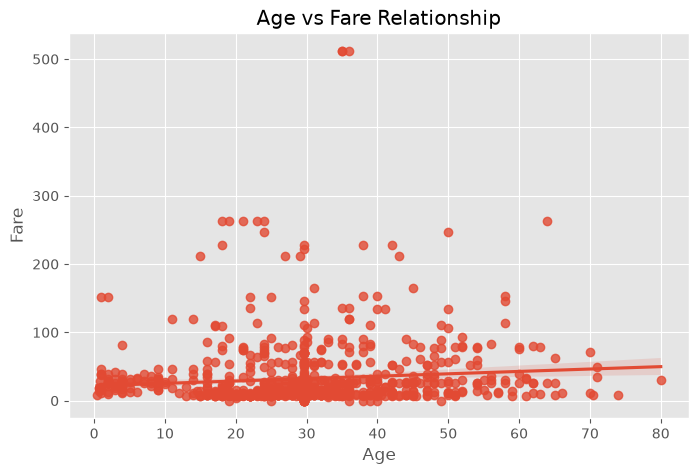

In [15]:
# Chart 6 Age vs Fare
plt.figure(figsize=(8,5))

sns.regplot(x='Age',
            y='Fare',
            data=df)

plt.title('Age vs Fare Relationship')

plt.savefig('../outputs/chart6_scatter.png')
plt.show()

There is only a weak relationship between passenger age and fare.

In [16]:
# Interactive Plotly Chart
fig = px.scatter(df,
                 x='Age',
                 y='Fare',
                 color='Sex',
                 title='Interactive Age vs Fare')

fig.show()

# Key Findings

1. Most passengers were aged between 20 and 40 years.

2. Third-class passengers represented the majority of travelers.

3. Male passengers were more frequent than female passengers.

4. The Fare variable contains significant outliers.

5. Passenger class strongly influenced ticket prices.

6. More passengers died than survived during the disaster.